Import pandas and nba_api teamgamelogs.
Get data of one game (all we need to get its columns)

In [1]:
import pandas as pd
from nba_api.stats.endpoints import teamgamelogs
log = teamgamelogs.TeamGameLogs(team_id_nullable='1610612737', season_nullable='2023-24', measure_type_player_game_logs_nullable='Advanced').get_data_frames()[0]

Create variable my_columns and make it a list of the columns of the game we got earlier.

In [2]:
my_columns = list(log.columns)
print (my_columns)

['SEASON_YEAR', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'GAME_ID', 'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'E_OFF_RATING', 'OFF_RATING', 'E_DEF_RATING', 'DEF_RATING', 'E_NET_RATING', 'NET_RATING', 'AST_PCT', 'AST_TO', 'AST_RATIO', 'OREB_PCT', 'DREB_PCT', 'REB_PCT', 'TM_TOV_PCT', 'EFG_PCT', 'TS_PCT', 'E_PACE', 'PACE', 'PACE_PER40', 'POSS', 'PIE', 'GP_RANK', 'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'OFF_RATING_RANK', 'DEF_RATING_RANK', 'NET_RATING_RANK', 'AST_PCT_RANK', 'AST_TO_RANK', 'AST_RATIO_RANK', 'OREB_PCT_RANK', 'DREB_PCT_RANK', 'REB_PCT_RANK', 'TM_TOV_PCT_RANK', 'EFG_PCT_RANK', 'TS_PCT_RANK', 'PACE_RANK', 'PIE_RANK', 'AVAILABLE_FLAG']


Create a dataframe using the csv we got from nba_api and create columns based on the list we created.

In [3]:
master_df = pd.read_csv('games.csv', header = None, names = my_columns)

Check head and shape of dataframe, make sure there are no surprises.

In [4]:
print(master_df.head())
print(master_df.shape)

  SEASON_YEAR     TEAM_ID TEAM_ABBREVIATION      TEAM_NAME   GAME_ID  \
0     2016-17  1610612737               ATL  Atlanta Hawks  41600136   
1     2016-17  1610612737               ATL  Atlanta Hawks  41600135   
2     2016-17  1610612737               ATL  Atlanta Hawks  41600134   
3     2016-17  1610612737               ATL  Atlanta Hawks  41600133   
4     2016-17  1610612737               ATL  Atlanta Hawks  41600132   

             GAME_DATE      MATCHUP WL   MIN  E_OFF_RATING  ...  \
0  2017-04-28T00:00:00  ATL vs. WAS  L  48.0         101.7  ...   
1  2017-04-26T00:00:00    ATL @ WAS  L  48.0          96.8  ...   
2  2017-04-24T00:00:00  ATL vs. WAS  W  48.0         109.9  ...   
3  2017-04-22T00:00:00  ATL vs. WAS  W  48.0         111.5  ...   
4  2017-04-19T00:00:00    ATL @ WAS  L  48.0          97.4  ...   

   AST_RATIO_RANK  OREB_PCT_RANK  DREB_PCT_RANK  REB_PCT_RANK  \
0              32             19             51            29   
1              58              9  

Because games are listed twice, once from each perspective, we need to merge them.

In [5]:
df = pd.merge(master_df, master_df, on='GAME_ID', suffixes=('_team', '_opp'))
matchup_df = df[df['TEAM_ID_team'] != df['TEAM_ID_opp']]

Create rest days column: convert dates to datetime object, sort by number, group based on team, and calculate numbers of days from previous game.

In [6]:
matchup_df['GAME_DATE_team'] = pd.to_datetime(matchup_df['GAME_DATE_team'])
matchup_df['REST_DAYS'] = matchup_df.sort_values('GAME_DATE_team').groupby('TEAM_ID_team')['GAME_DATE_team'].diff().dt.days

Dropping first games of each season (no relevant rest days data).
Dropping all rows where the rest days are more than 9.

In [7]:
matchup_df = matchup_df.dropna()
matchup_df = matchup_df[matchup_df["REST_DAYS"] < 9]

Lag columns by 1 game so they don't "see the future".

In [8]:
target_cols = ["OFF_RATING_team", "DEF_RATING_team", "PACE_team"]
lagged_cols = ["prev_OFF_RATING", "prev_DEF_RATING", "prev_PACE"]

matchup_df[lagged_cols] = matchup_df.sort_values('GAME_DATE_team').groupby('TEAM_ID_team')[target_cols].shift(1)

matchup_df = matchup_df.dropna()

Visualizing the data using a scatterplot, can't reach a definite conclusion based on the human eye, need to create a heatmap.

Creating a matrix using .corr() and creating a heatmap of said matrix.

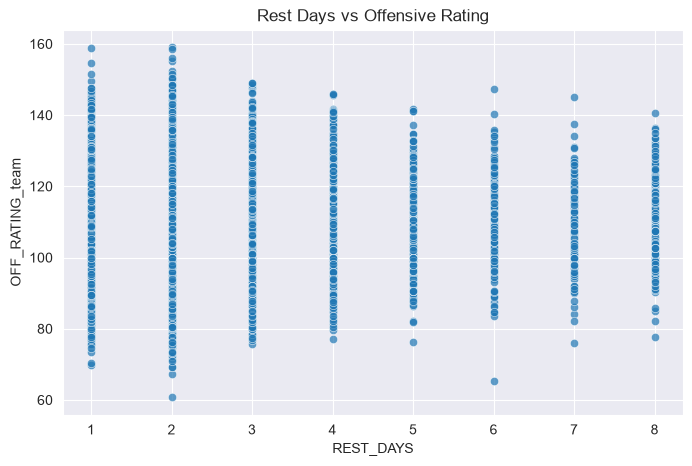

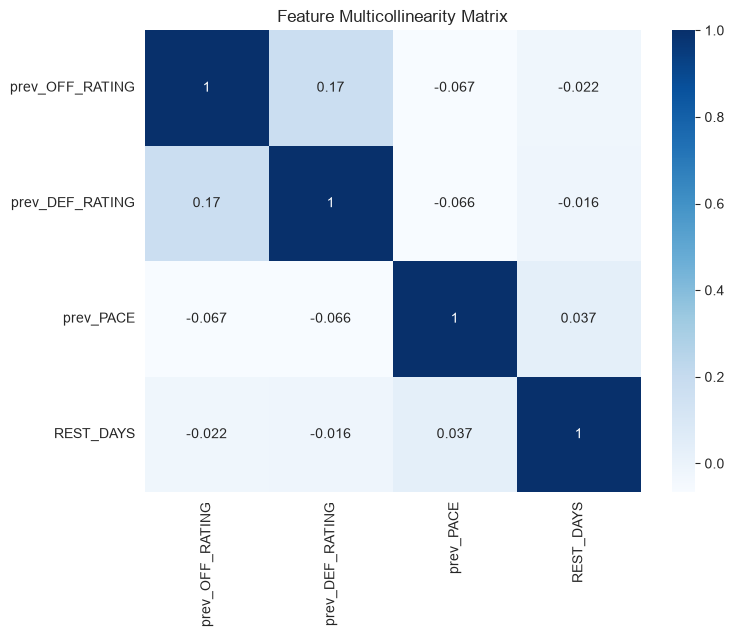

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.scatterplot(data=matchup_df, x='REST_DAYS', y='OFF_RATING_team', alpha=0.7)
plt.title('Rest Days vs Offensive Rating')
plt.savefig('scatter.png', dpi=300, bbox_inches='tight')

plt.figure(figsize=(8, 6))
cols = ['prev_OFF_RATING', 'prev_DEF_RATING', 'prev_PACE', 'REST_DAYS']
sns.heatmap(matchup_df[cols].corr(), annot=True, cmap='Blues')
plt.title('Feature Multicollinearity Matrix')
plt.savefig('heatmap.png', dpi=300, bbox_inches='tight')

Create new column with 1s and 0s detailing whether a team won or lost a matchup.

In [11]:
matchup_df["TARGET_WIN"] = matchup_df["WL_team"].str.contains("W", na=False).astype(int)

Import train_test_split function of scikit_learn. Define matrix "X" as 4 columns that we want to train the model with. Define vector "y" as prediction. Train_size = 0.8 means that the first top 80% of data will be used to train the model, and the bottom 20% will be used to test the model's accuracy. Because shuffle is off, and we put the games in chronological order, this makes sense as we are training the model on older seasons but testing it on the most recent.
Additionally, we import StandardScaler and use it to transform X into a matrix with variables that are all on same scale with z-scores that we can easily compare to each other. This makes rest days and offensive rating able to be compared to each other, and then we can see which is more statistically significant.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Define Features and Target
X = matchup_df[['prev_OFF_RATING', 'prev_DEF_RATING', 'prev_PACE', 'REST_DAYS']]
y = matchup_df['TARGET_WIN']

# 2. Chronological Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, shuffle=False
)

# 3. Scale SECOND (Fit ONLY on training data)
scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train)
X_scaled_test = scaler.transform(X_test)

Bringing the model online: pulling engine from library, creating blank instance of model (pass max_iter = 1000 to give the algorithm enough runway to compute), and commanding the model based on the variables and parameters we defined earlier.

In [13]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_scaled_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

Generating model's predictions using .predict()

In [14]:
y_pred = log_model.predict(X_scaled_test)

Comparing the test and model using accuracy_score function.

In [15]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2%}")

Accuracy: 54.47%


In [16]:
for feature, weight in zip(X.columns, log_model.coef_[0]):
    print(f"{feature}: {weight}")

prev_OFF_RATING: 0.13659541704019867
prev_DEF_RATING: -0.13129548488160742
prev_PACE: -0.014503575031547667
REST_DAYS: 0.06632915638057914
